Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2892 - loss: 1.9434 - val_accuracy: 0.3666 - val_loss: 1.7699
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3568 - loss: 1.7830 - val_accuracy: 0.3995 - val_loss: 1.6724
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3765 - loss: 1.7241 - val_accuracy: 0.4266 - val_loss: 1.6283
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3950 - loss: 1.6828 - val_accuracy: 0.4272 - val_loss: 1.6257
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4023 - loss: 1.6534 - val_accuracy: 0.4402 - val_loss: 1.5793
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4110 - loss: 1.6300 - val_accuracy: 0.4530 - val_loss: 1.5578
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4161 - loss: 1.6112 - val_accuracy: 0.4529 - val_loss: 1.5437
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4255 - loss: 1.5929 - val_accuracy: 0.

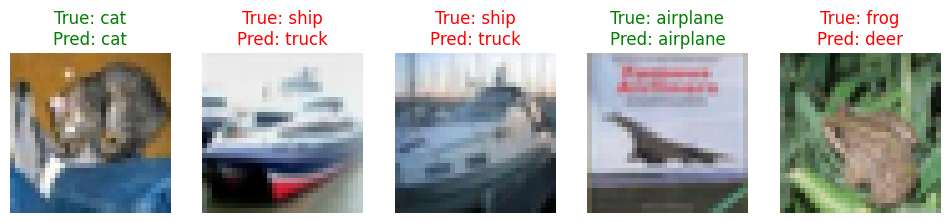

In [5]:
# bai 1

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải bộ dữ liệu CIFAR-10 có sẵn trong TensorFlow
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Đặt tên các nhãn theo đúng bảng mô tả
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 2. Tiền xử lý dữ liệu (Chuẩn hóa giá trị pixel về đoạn [0, 1])
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. Xây dựng cấu trúc mạng ANN (Mạng nơ-ron truyền thẳng)
model = models.Sequential([
    # Lớp Flatten để chuyển ảnh 3D (32x32x3) thành vector 1D (3072 phần tử)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Các lớp ẩn (Hidden Layers) với hàm kích hoạt ReLU
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2), # Dropout để giảm thiểu tình trạng Overfitting
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra (Output Layer) với 10 nơ-ron tương ứng với 10 lớp
    # Sử dụng activation='softmax' để xuất ra xác suất của từng lớp
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc mạng
model.summary()

# 4. Biên dịch mô hình (Compile)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Phù hợp khi y_train là số nguyên (0 đến 9)
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình (Training)
EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test)
)

# 6. Đánh giá mô hình trên tập kiểm tra (Test Set)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# 7. Dự đoán thử nghiệm một vài hình ảnh
predictions = model.predict(X_test)

# Hàm vẽ biểu đồ trực quan kết quả dự đoán
def plot_sample_predictions(images, labels, preds, start_idx=0):
    plt.figure(figsize=(12, 6))
    for i in range(5):
        idx = start_idx + i
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx])

        pred_label = np.argmax(preds[idx])
        true_label = labels[idx][0]

        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color=color)
        plt.axis('off')
    plt.show()

# Hiển thị kết quả dự đoán của 5 ảnh đầu tiên trong tập test
plot_sample_predictions(X_test, y_test, predictions, start_idx=0)

In [13]:
# Chạy lệnh này trên Colab để tải và giải nén dữ liệu nhanh
!wget --no-check-certificate https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
!unzip -q cats_and_dogs_filtered.zip

# Tổ chức lại thư mục thành 'train' để khớp với code của giảng viên
!mkdir -p train
!cp -r cats_and_dogs_filtered/train/cats/* train/
!cp -r cats_and_dogs_filtered/train/dogs/* train/

Đang tải xuống và chuẩn bị bộ dữ liệu Cats vs Dogs từ TensorFlow Datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.XBF4MX_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Đã tải xuống và chuẩn bị bộ dữ liệu xong.
Đang xử lý và lưu hình ảnh vào thư mục 'train/'...
Đã lưu tổng cộng 23262 hình ảnh vào thư mục 'train/'.
Bây giờ bạn có thể chạy tiếp các ô mã để tạo file .npy và huấn luyện mô hình.


In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tqdm import tqdm

# Số lượng ảnh mong muốn (ví dụ: 2000 ảnh để chạy nhanh)
NUM_SAMPLES = 2000

print(f"Đang tải {NUM_SAMPLES} ảnh từ TFDS để chuyển đổi sang NumPy...")
# Lấy một phần nhỏ dữ liệu bằng .take()
dataset = tfds.load('cats_vs_dogs', split='train', as_supervised=True)
dataset = dataset.take(NUM_SAMPLES)

photos = []
labels = []

for image, label in tqdm(dataset, total=NUM_SAMPLES):
    # Chuyển tensor sang mảng và resize về 200x200
    img = tf.image.resize(image, (200, 200)).numpy()
    photos.append(img)
    labels.append(float(label.numpy()))

# Chuyển sang mảng NumPy
photos = np.asarray(photos)
labels = np.asarray(labels)

print(f"\nKích thước dữ liệu cuối cùng: {photos.shape}, {labels.shape}")

# Lưu tệp .npy
np.save('dogs_vs_cats_photos.npy', photos)
np.save('dogs_vs_cats_labels.npy', labels)
print("Đã lưu thành công dữ liệu rút gọn vào dogs_vs_cats_photos.npy và dogs_vs_cats_labels.npy!")

Đang tải 2000 ảnh từ TFDS để chuyển đổi sang NumPy...


100%|██████████| 2000/2000 [00:07<00:00, 255.59it/s]



Kích thước dữ liệu cuối cùng: (2000, 200, 200, 3), (2000,)
Đã lưu thành công dữ liệu rút gọn vào dogs_vs_cats_photos.npy và dogs_vs_cats_labels.npy!


Đang nạp dữ liệu từ file .npy...
Tập huấn luyện: 1600 mẫu
Tập kiểm tra: 400 mẫu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Bắt đầu huấn luyện...
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5088 - loss: 8.3337 - val_accuracy: 0.5350 - val_loss: 0.8150
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4931 - loss: 1.6991 - val_accuracy: 0.5025 - val_loss: 0.6902
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5156 - loss: 0.6907 - val_accuracy: 0.4950 - val_loss: 0.6919
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5138 - loss: 0.6885 - val_accuracy: 0.4975 - val_loss: 0.6880
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5150 - loss: 0.6850 - val_accuracy: 0.4950 - val_loss: 0.6983
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5144 - loss: 0.6901 - val_accuracy: 0.4950 - val_loss: 0.6943
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5138 - loss: 0.6923 - val_accuracy: 0.4950 - val_loss: 0.6938
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5163 - loss: 0.6917 - va

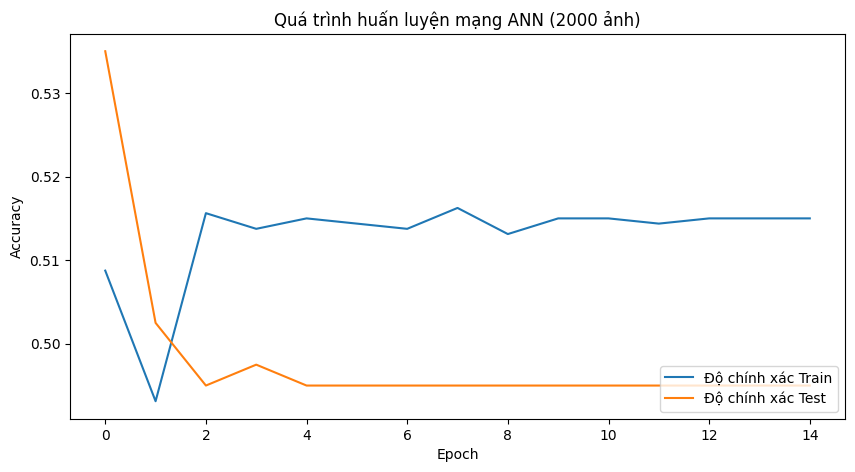

In [2]:
# bai 3

import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Nạp dữ liệu từ file .npy đã lưu (2000 mẫu)
print("Đang nạp dữ liệu từ file .npy...")
X = np.load('dogs_vs_cats_photos.npy')
y = np.load('dogs_vs_cats_labels.npy')

# 2. Chuẩn hóa dữ liệu ảnh về đoạn [0, 1]
X = X.astype('float32') / 255.0

# 3. Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tập huấn luyện: {X_train.shape[0]} mẫu")
print(f"Tập kiểm tra: {X_test.shape[0]} mẫu")

# 4. Xây dựng cấu trúc mạng ANN
model = models.Sequential([
    layers.Flatten(input_shape=(200, 200, 3)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 5. Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
print("Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# 7. Đánh giá kết quả trên tập Test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# 8. Vẽ đồ thị kết quả độ chính xác
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Độ chính xác Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Quá trình huấn luyện mạng ANN (2000 ảnh)')
plt.show()

Dữ liệu mẫu 5 dòng đầu tiên:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1            

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8098 - loss: 0.4065 - val_accuracy: 0.8449 - val_loss: 0.3370
Epoch 2/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8350 - loss: 0.3493 - val_accuracy: 0.8506 - val_loss: 0.3255
Epoch 3/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8404 - loss: 0.3410 - val_accuracy: 0.8511 - val_loss: 0.3231
Epoch 4/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.3364 - val_accuracy: 0.8523 - val_loss: 0.3205
Epoch 5/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8452 - loss: 0.3346 - val_accuracy: 0.8512 - val_loss: 0.3204
Epoch 6/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3315 - val_accuracy: 0.8548 - val_loss: 0.3182
Epoch 7/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8465 - loss: 0.3302 - val_accuracy: 0.8563 - val_loss: 0.3175
Epoch 8/30
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3287 - val_accuracy: 0.8540 - val_

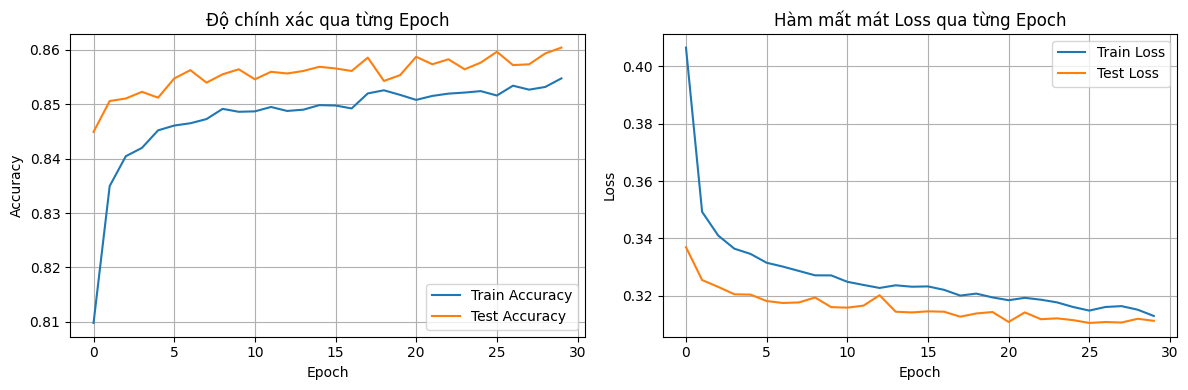

In [6]:
#bai 4

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# BƯỚC 1: TẢI DỮ LIỆU TRỰC TIẾP TỪ UCI
# ==========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Định nghĩa tên cho 15 cột của bộ dữ liệu Adult
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Đọc dữ liệu (bộ dữ liệu này dùng dấu phẩy kèm khoảng trắng nên cần skipinitialspace=True)
df = pd.read_csv(url, names=column_names, skipinitialspace=True)
print("Dữ liệu mẫu 5 dòng đầu tiên:")
print(df.head(5))

# ==========================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
# 1. Xử lý dữ liệu thiếu: Trong bộ dữ liệu này, giá trị thiếu ký hiệu là '?'
# Chúng ta thay thế '?' bằng giá trị xuất hiện nhiều nhất (mode) của cột đó
for col in df.columns:
    if df[col].dtype == 'object':
        mode_val = df[col].mode()[0]
        df[col] = df[col].replace('?', mode_val)

# 2. Mã hóa các cột dạng chữ (Categorical) thành dạng số bằng LabelEncoder
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Sau khi mã hóa cột 'income' (nhãn cuối):
# <=50K sẽ thành số 0, và >50K sẽ thành số 1

# 3. Tách đặc trưng (X) và nhãn (y)
X = df.drop(columns=['income']).values
y = df['income'].values

# 4. Chuẩn hóa thang đo (Feature Scaling)
# Bộ dữ liệu này có các cột số lệch nhau rất lớn (ví dụ tuổi ~40, nhưng fnlwgt ~200,000).
# Ta cần chuẩn hóa bằng StandardScaler để mạng ANN học tốt hơn hẳn.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 5. Chia tập Train (80%) và tập Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nSố lượng mẫu tập huấn luyện: {X_train.shape[0]}")
print(f"Số lượng mẫu tập kiểm tra: {X_test.shape[0]}")

# ==========================================
# BƯỚC 3: XÂY DỰNG MẠNG ANN PHÂN LOẠI NHỊ PHÂN
# ==========================================
model = models.Sequential([
    # Input đầu vào là số lượng đặc trưng (14 cột đặc trưng)
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    layers.Dropout(0.2), # Dùng Dropout để chống overfitting dữ liệu bảng lớn
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),

    # Lớp đầu ra chỉ cần 1 nơ-ron với hàm kích hoạt sigmoid (0 hoặc 1)
    layers.Dense(1, activation='sigmoid')
])

# Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Thích hợp nhất cho bài toán phân loại nhị phân
    metrics=['accuracy']
)

# ==========================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\nBắt đầu huấn luyện mạng ANN...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ VÀ TRỰC QUAN HÓA KẾT QUẢ
# ==========================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# Vẽ đồ thị kết quả huấn luyện
plt.figure(figsize=(12, 4))

# Đồ thị độ chính xác
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Độ chính xác qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Đồ thị giá trị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Hàm mất mát Loss qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

5 dòng dữ liệu mẫu đầu tiên tải về:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc

Số lượng đặc trưng đầu vào: 6
Số lượng nhãn phân loại đầu ra: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Bắt đầu huấn luyện mạng ANN...
Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6252 - loss: 1.0301 - val_accuracy: 0.6792 - val_loss: 0.8286
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7012 - loss: 0.7320 - val_accuracy: 0.6879 - val_loss: 0.7116
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7192 - loss: 0.6602 - val_accuracy: 0.6618 - val_loss: 0.6687
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7279 - loss: 0.6152 - val_accuracy: 0.7139 - val_loss: 0.6246
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.5487 - val_accuracy: 0.7919 - val_loss: 0.5301
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8177 - loss: 0.4579 - val_accuracy: 0.8064 - val_loss: 0.4399
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8488 - loss: 0.3906 - val_accuracy: 0.8064 - val_loss: 0.4043
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8553 - loss: 0.3552 -

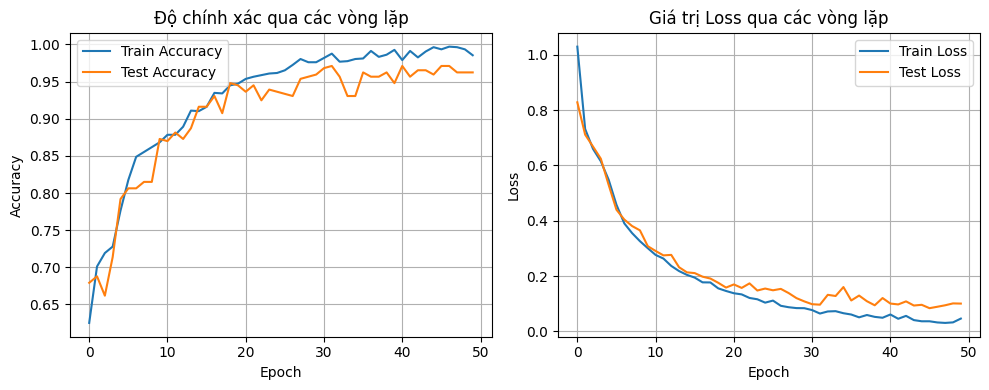

In [3]:
#bai 5

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ==========================================
# BƯỚC 1: TẢI DỮ LIỆU TRỰC TIẾP TỪ UCI
# ==========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

# Đặt tên cho các cột theo đúng mô tả cấu trúc bộ dữ liệu Car Evaluation
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Đọc dữ liệu vào DataFrame
df = pd.read_csv(url, names=column_names)
print("5 dòng dữ liệu mẫu đầu tiên tải về:")
print(df.head())

# ==========================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU (MÃ HÓA CHỮ THÀNH SỐ)
# ==========================================
# Vì các cột đều là dạng chữ (categorical), ta cần dùng LabelEncoder để chuyển về dạng số
label_encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Tách đặc trưng (X) và nhãn cuối cùng cần dự báo (y)
X = df.drop(columns=['class']).values
y = df['class'].values

# Xác định số lượng lớp ở nhãn cuối cùng (thường là 4 lớp: unacc, acc, good, vgood)
num_classes = len(np.unique(y))
print(f"\nSố lượng đặc trưng đầu vào: {X.shape[1]}")
print(f"Số lượng nhãn phân loại đầu ra: {num_classes}")

# Chia dữ liệu thành tập Train (80%) và tập Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 3: XÂY DỰNG MẠNG ANN CHO DỮ LIỆU BẢNG
# ==========================================
model = models.Sequential([
    # Khác với xử lý ảnh, dữ liệu bảng ở đây đã là vector phẳng nên không cần lớp Flatten nữa
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    # Lớp đầu ra tương ứng với số lượng nhãn chất lượng xe
    layers.Dense(num_classes, activation='softmax')
])

# Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Dùng khi nhãn y là các số nguyên độc lập (0, 1, 2, 3)
    metrics=['accuracy']
)

# ==========================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\nBắt đầu huấn luyện mạng ANN...")
history = model.fit(
    X_train, y_train,
    epochs=50,             # Dữ liệu bảng tính toán rất nhanh nên có thể tăng số epoch lên
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ VÀ TRỰC QUAN HÓA KẾT QUẢ
# ==========================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# Vẽ đồ thị kết quả
plt.figure(figsize=(10, 4))

# Đồ thị độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Độ chính xác qua các vòng lặp')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Đồ thị hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Giá trị Loss qua các vòng lặp')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()